# Breast Cancer Classification

## Problem
Breast cancer is an abnormal growth of cells in the breast. It is the most common cancer in women in the United States, accounting for about 30% of new cancer diagnoses in women, and the second leading cause of cancer death among women after lung cancer (American Cancer Society).

## Goal
These abnormal growths form tumors, which can be benign or malignant. Because the dataset labels are discrete categories of malignant (1) or benign (0), this is a classification problem. The goal of this notebook is to apply several machine learning techniques to classify tumor masses using data from Wisconsin patients, identifying key predictive attributes and understanding how they contribute to accurate classification.

In [2]:
# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Keep the notebook output clean and the plot style consistent.
warnings.filterwarnings("ignore")
%matplotlib inline
plt.style.use("fivethirtyeight")
sns.set_style("white")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

# One fixed random seed so every run of this notebook gives the same numbers.
RANDOM_SEED = 42

In [3]:
# Scikit-learn tools: preprocessing, pipelines, model selection and metrics.
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.inspection import permutation_importance

# The seven classification algorithms used in this project.
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier   # install with: pip install xgboost

# Metrics 
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

In [4]:
# Load the data
df = pd.read_csv("Breast Cancer dataset.csv")

print("rows and cols:", df.shape)
df.head()

rows and cols: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


# 1. Data check
Lets validate the raw data first: missing values, duplicated rows, and impossible values...


In [5]:
# Clean the raw file:
#   - 'id' it carries no medical signal, so we drop it.
#   - 'Unnamed: 32' is an empty column -> we drop too.
#   - 'diagnosis' is text (M/B), so we turn it into a number the models can use.

cancer_df = df.copy()

columns_to_drop = [c for c in ["id", "Unnamed: 32"] if c in cancer_df.columns]
cancer_df = cancer_df.drop(columns=columns_to_drop)

# Map the diagnosis: Malignant (cancer) = 1, Benign (no cancer) = 0.
cancer_df["target"] = cancer_df["diagnosis"].map({"M": 1, "B": 0})
cancer_df = cancer_df.drop(columns=["diagnosis"])

print("Dropped columns:", columns_to_drop)
print("Shape after cleaning:", cancer_df.shape)
print("\nTarget meaning -> 1 = Malignant, 0 = Benign")
cancer_df.head()

Dropped columns: ['id', 'Unnamed: 32']
Shape after cleaning: (569, 31)

Target meaning -> 1 = Malignant, 0 = Benign


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


In [6]:
# Count duplicate rows (identical across every column)
duplicate_rows_before = cancer_df.duplicated().sum()

# Check missing values per column. 
# markers like "?" or "N/A" are still stored as plain text and have not been converted yet.
missing_before = cancer_df.isna().sum()
missing_before = missing_before[missing_before > 0].sort_values(ascending=False)

print(f"Duplicate rows found: {duplicate_rows_before}")
print("\nColumns with missing values:")
display(missing_before.to_frame("missing_count"))

Duplicate rows found: 0

Columns with missing values:


,missing_count


**Interpretation.** The dataset has now 569 patients and 30 diagnostic atrributes + target, after
removing the ID column and the empty column. 

There is no need of imputation -> 0 missing values and no duplicates.

# 2. EDA

In [7]:
# A quick structural summary: 
cancer_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   radius_mean              569 non-null    float64
 1   texture_mean             569 non-null    float64
 2   perimeter_mean           569 non-null    float64
 3   area_mean                569 non-null    float64
 4   smoothness_mean          569 non-null    float64
 5   compactness_mean         569 non-null    float64
 6   concavity_mean           569 non-null    float64
 7   concave points_mean      569 non-null    float64
 8   symmetry_mean            569 non-null    float64
 9   fractal_dimension_mean   569 non-null    float64
 10  radius_se                569 non-null    float64
 11  texture_se               569 non-null    float64
 12  perimeter_se             569 non-null    float64
 13  area_se                  569 non-null    float64
 14  smoothness_se            569 non-null

In [8]:
# Descriptive statistics: mean, standard deviation, min, max and quartiles per column.
# This is the fastest way to spot columns measured on very different scales.
cancer_df.describe().T

,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
fractal_dimension_mean,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


**Interpretation.** Every column is numeric and fully populated. The scales are very
different: `area_mean` or `area_worst`  runs into the hundreds while `smoothness_mean` sits around 0.1. Standardisation is needed before applying distance-based models such as
KNN or SVM.

Benign (0):    357 patients -> 62.7 %
Malignant (1): 212 patients -> 37.3 %


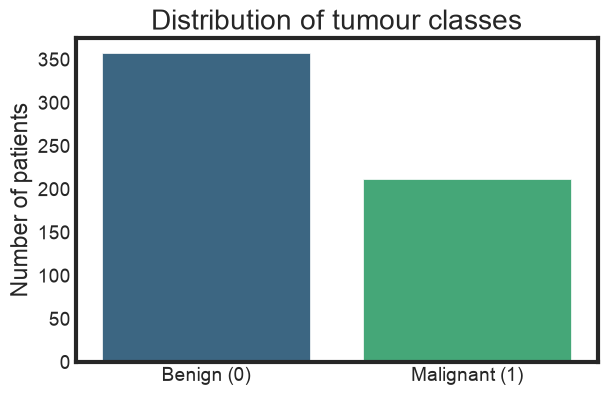

In [9]:
# Count how many patients fall into each class 
class_counts = cancer_df["target"].value_counts().sort_index()
class_percentages = (class_counts / len(cancer_df) * 100).round(1)

print("Benign (0):   ", class_counts[0], "patients ->", class_percentages[0], "%")
print("Malignant (1):", class_counts[1], "patients ->", class_percentages[1], "%")

plt.figure(figsize=(6, 4))
sns.countplot(x="target", data=cancer_df, palette="viridis")
plt.xticks([0, 1], ["Benign (0)", "Malignant (1)"])
plt.title("Distribution of tumour classes")
plt.xlabel("")
plt.ylabel("Number of patients")
plt.show()

**Interpretation.** The classes are unbalanced: 63% benign vs
37% malignant. This is mild enough that we do not need resampling, but it is the reason we
use **stratified** splitting and report recall and ROC-AUC rather than accuracy alone.

**Note:** stratified splitting vs. resampling, and accuracy vs. ROC-AUC

- **Stratified split** keeps the same class ratio in train/test 
- **Resampling** (SMOTE, class weights, etc.) rebalances the *training* data itself.
  Needed only for severe imbalance (~90/10+), where a model can get high accuracy by
  just predicting the majority class.
- Here the imbalance is mild (~63/37), so stratified splitting is enough.

- **Accuracy is misleading**: it's just "% correct overall." Always predicting
  "benign" would already score ~63% while missing every cancer -> useless model can
  still look good.
- **ROC-AUC is more robust**: it measures how well the model separates the two classes
  across all thresholds (0.5 = random, 1.0 = perfect), since TPR/FPR are each computed
  *within* their own class rather than as one overall accuracy number. Still, under
  severe imbalance it can look optimistic; PR-AUC is a better check then.
- **Recall on malignant** answers "of all real cancer cases, how many did we catch?". The clearest measure of missed cancers, hence the focus on it here.

In [10]:
# Lets create first a comparison table that is going to be quicker
# Compare the average value of each 'mean' measurement for benign vs malignant tumours.
mean_feature_names = [c for c in cancer_df.columns if c.endswith("_mean")]

class_comparison_table = cancer_df.groupby("target")[mean_feature_names].mean().T
class_comparison_table.columns = ["Benign_average", "Malignant_average"]

# 'Ratio' tells us how many times larger the malignant average is.
class_comparison_table["Ratio_malignant_over_benign"] = (
    class_comparison_table["Malignant_average"] / class_comparison_table["Benign_average"]
).round(2)

class_comparison_table.sort_values("Ratio_malignant_over_benign", ascending=False).round(3)

,Benign_average,Malignant_average,Ratio_malignant_over_benign
concavity_mean,0.046,0.161,3.49
concave points_mean,0.026,0.088,3.42
area_mean,462.790,978.376,2.11
compactness_mean,0.080,0.145,1.81
perimeter_mean,78.075,115.365,1.48
radius_mean,12.147,17.463,1.44
texture_mean,17.915,21.605,1.21
smoothness_mean,0.092,0.103,1.11
symmetry_mean,0.174,0.193,1.11
fractal_dimension_mean,0.063,0.063,1.00


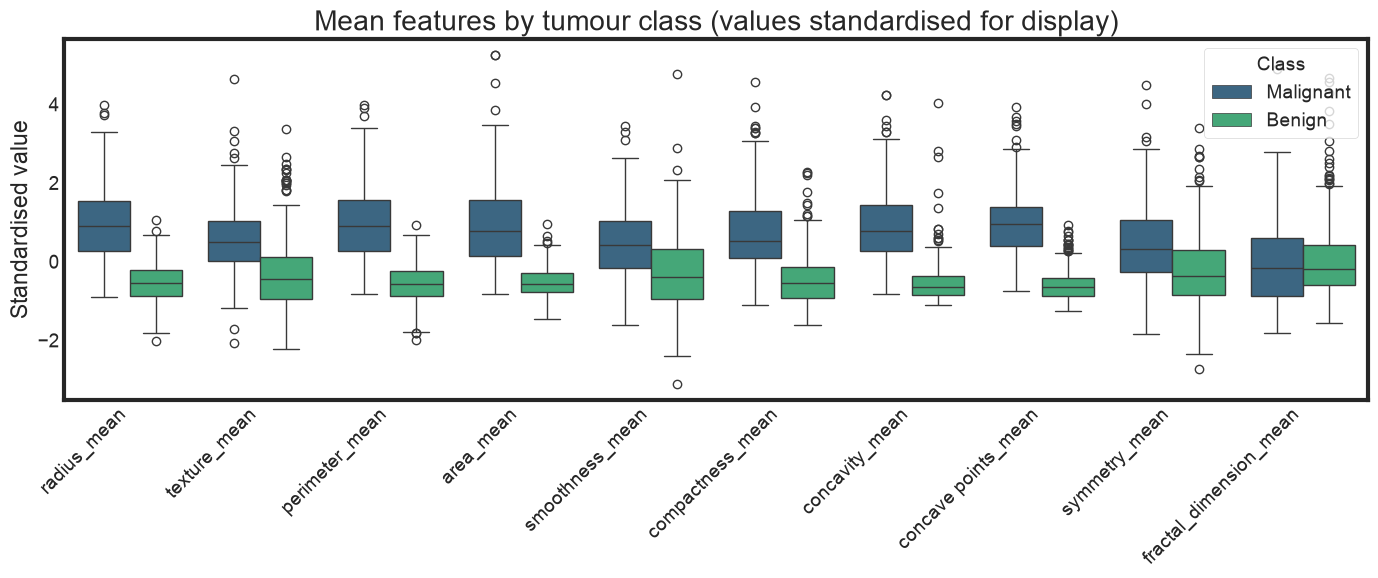

In [11]:
# Box plots make the separation between the two classes easy to see for each feature.
# We standardise first purely for display, so all features fit on the same axis.
features_to_plot = mean_feature_names
plot_data = cancer_df[features_to_plot].copy()
plot_data = (plot_data - plot_data.mean()) / plot_data.std()   # display-only scaling
plot_data["target"] = cancer_df["target"].map({0: "Benign", 1: "Malignant"})

long_format_data = plot_data.melt(id_vars="target", var_name="feature", value_name="scaled_value")

plt.figure(figsize=(14, 6))
sns.boxplot(x="feature", y="scaled_value", hue="target", data=long_format_data, palette="viridis")
plt.xticks(rotation=45, ha="right")
plt.title("Mean features by tumour class (values standardised for display)")
plt.xlabel("")
plt.ylabel("Standardised value")
plt.legend(title="Class")
plt.tight_layout()
plt.show()

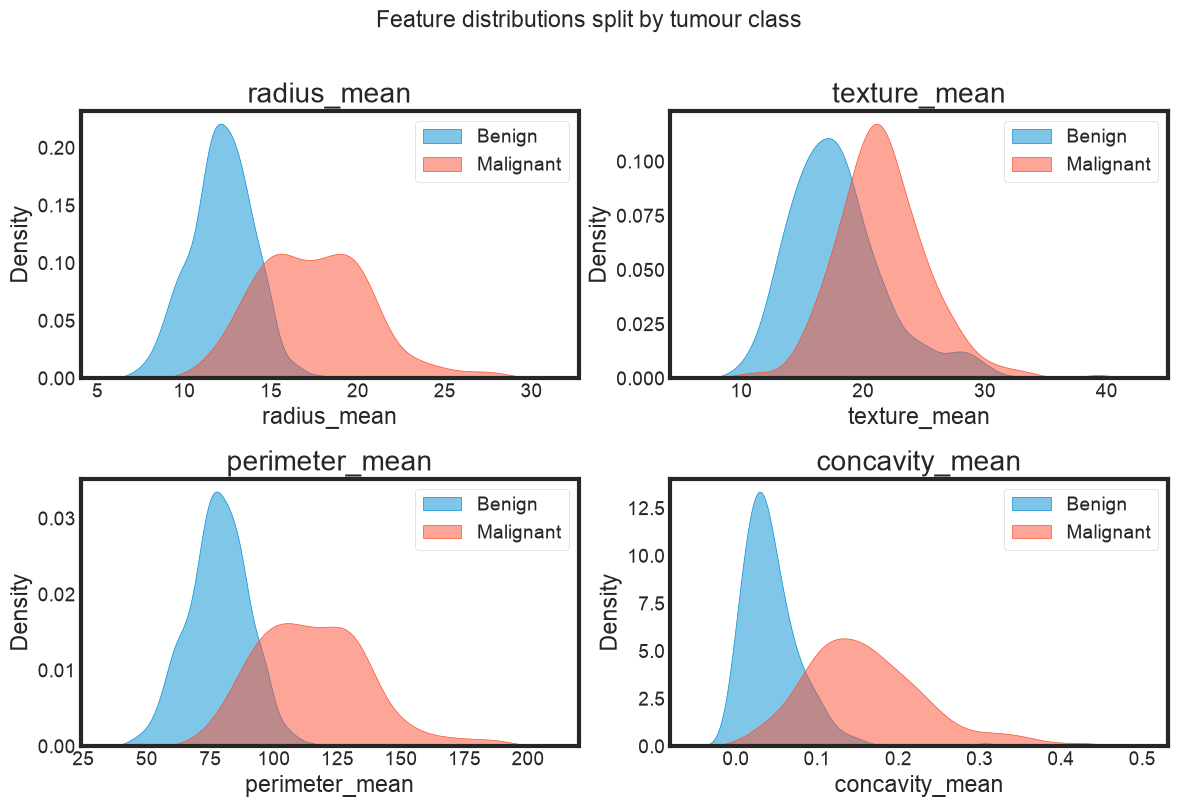

In [12]:
# Density curves
headline_features = ["radius_mean", "texture_mean", "perimeter_mean", "concavity_mean"]

figure, axes = plt.subplots(2, 2, figsize=(12, 8))
for axis, feature_name in zip(axes.ravel(), headline_features):
    for class_value, class_label in [(0, "Benign"), (1, "Malignant")]:
        subset = cancer_df.loc[cancer_df["target"] == class_value, feature_name]
        sns.kdeplot(subset, ax=axis, fill=True, label=class_label, alpha=0.5)
    axis.set_title(feature_name)
    axis.legend()
plt.suptitle("Feature distributions split by tumour class", y=1.01)
plt.tight_layout()
plt.show()

**Interpretation.** Malignant tumours are more irregular. The biggest
gaps are in border shape rather than raw size: `concavity_mean` is about 3.5 times higher in
malignant tumours and `concave points_mean` about 3.4 times higher, while `area_mean` is
about 2.1 times larger and radius and perimeter only about 1.4 to 1.5 times larger.
`fractal_dimension_mean` is essentially identical in both groups (ratio 1.00), so on its own
it carries no signal. This already tells us which measurements the models will lean on.

In [13]:
# Measure skewness for every predictor. A value near 0 means a symmetric distribution;
# anything above about 1 is considered strongly right-skewed.
# Very skewed features can hurt models that assume roughly symmetric inputs, 
# such as Gaussian Naive Bayes.
predictor_columns = [c for c in cancer_df.columns if c != "target"]
skewness_values = cancer_df[predictor_columns].skew().sort_values(ascending=False)

skewness_summary = pd.DataFrame({"skewness": skewness_values.round(2)})
skewness_summary["interpretation"] = np.where(
    skewness_summary["skewness"].abs() > 1, "strongly skewed",
    np.where(skewness_summary["skewness"].abs() > 0.5, "moderately skewed", "roughly symmetric"))

print("Number of strongly skewed features:", int((skewness_values.abs() > 1).sum()), "out of", len(predictor_columns))
skewness_summary.head(10)

Number of strongly skewed features: 22 out of 30


,skewness,interpretation
area_se,5.45,strongly skewed
concavity_se,5.11,strongly skewed
fractal_dimension_se,3.92,strongly skewed
perimeter_se,3.44,strongly skewed
radius_se,3.09,strongly skewed
smoothness_se,2.31,strongly skewed
symmetry_se,2.20,strongly skewed
compactness_se,1.90,strongly skewed
area_worst,1.86,strongly skewed
fractal_dimension_worst,1.66,strongly skewed


In [14]:
# Outlier detection (quantify)
def count_outliers_with_iqr_rule(dataframe, column_names):
    """Return how many values in each column fall outside the 1.5 * IQR fences."""
    outlier_counts = {}
    for column_name in column_names:
        first_quartile = dataframe[column_name].quantile(0.25)
        third_quartile = dataframe[column_name].quantile(0.75)
        interquartile_range = third_quartile - first_quartile
        lower_fence = first_quartile - 1.5 * interquartile_range
        upper_fence = third_quartile + 1.5 * interquartile_range
        is_outlier = (dataframe[column_name] < lower_fence) | (dataframe[column_name] > upper_fence)
        outlier_counts[column_name] = int(is_outlier.sum())
    return pd.Series(outlier_counts).sort_values(ascending=False)

# Apply the rule to every predictor column.
outlier_counts_per_feature = count_outliers_with_iqr_rule(cancer_df, predictor_columns)
outlier_percentage = (outlier_counts_per_feature / len(cancer_df) * 100).round(1)

outlier_summary = pd.DataFrame({"outlier_count": outlier_counts_per_feature,
                                "percent_of_rows": outlier_percentage})
print("Total outlier values flagged across all features:", int(outlier_counts_per_feature.sum()))
outlier_summary.head(10)

Total outlier values flagged across all features: 608


,outlier_count,percent_of_rows
area_se,65,11.4
radius_se,38,6.7
perimeter_se,38,6.7
area_worst,35,6.2
smoothness_se,30,5.3
fractal_dimension_se,28,4.9
compactness_se,28,4.9
symmetry_se,27,4.7
area_mean,25,4.4
fractal_dimension_worst,24,4.2


**Interpretation.**

* **Findings:** 608 values are flagged, mainly concentrated in skewed "standard error" columns (like `area_se`). 
* **Cause:** These represent genuine large tumors rather than data-entry errors. This is an assumption. 
* **Action:** **Cap** the values instead of deleting rows, ensuring the model retains crucial severe cases to learn from.

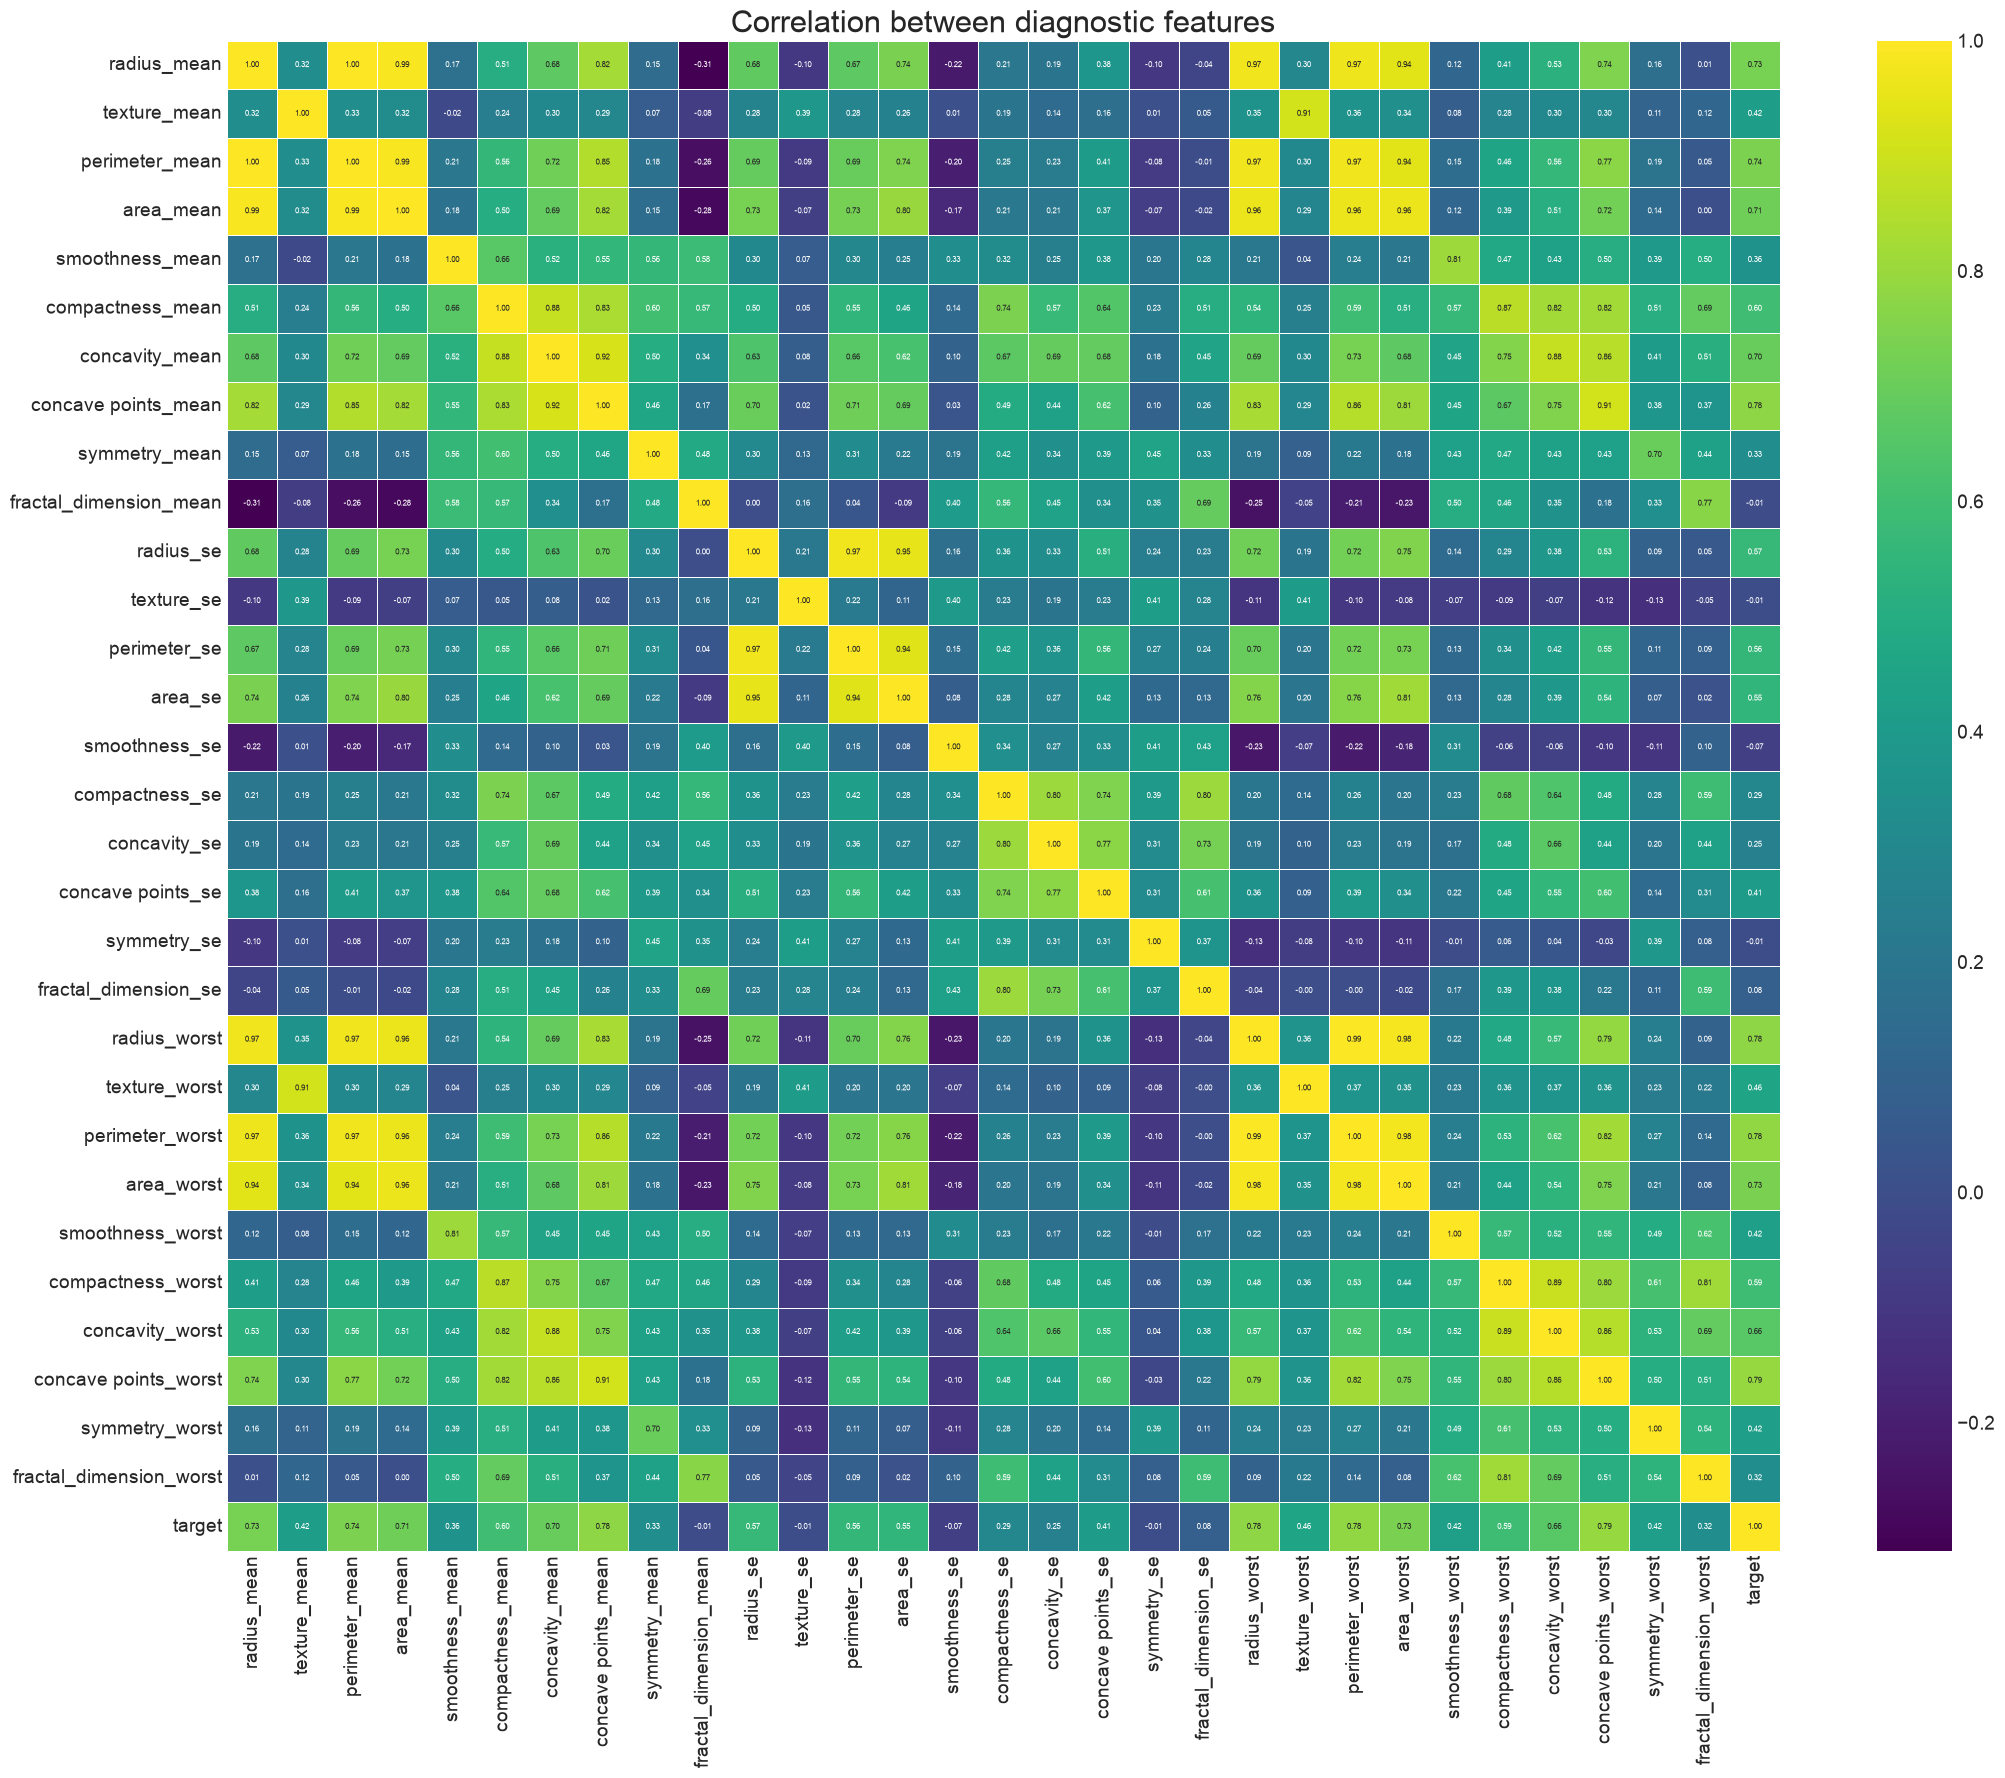

In [15]:
# Corrleation
# Correlation heatmap for all 30 predictors plus the target.
plt.figure(figsize=(22, 18))
correlation_matrix = cancer_df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", annot_kws={"size": 6},
            linewidths=0.5, cmap="viridis")
plt.title("Correlation between diagnostic features", fontsize=22)
plt.tight_layout()
plt.show()

In [16]:
# Since the heatmap is so large -> List the feature pairs that are almost saying the same thing (correlation above 0.9).
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

highly_correlated_pairs = (upper_triangle.stack()
                           .reset_index()
                           .rename(columns={"level_0": "feature_a", "level_1": "feature_b", 0: "correlation"}))
highly_correlated_pairs = highly_correlated_pairs[
    (highly_correlated_pairs["correlation"].abs() > 0.9) &
    (highly_correlated_pairs["feature_a"] != "target") &
    (highly_correlated_pairs["feature_b"] != "target")].sort_values("correlation", ascending=False)

print("Number of feature pairs correlated above 0.9:", len(highly_correlated_pairs))
highly_correlated_pairs.head(12).round(3)

Number of feature pairs correlated above 0.9: 21


,feature_a,feature_b,correlation
2,radius_mean,perimeter_mean,0.998
642,radius_worst,perimeter_worst,0.994
3,radius_mean,area_mean,0.987
65,perimeter_mean,area_mean,0.987
643,radius_worst,area_worst,0.984
705,perimeter_worst,area_worst,0.978
322,radius_se,perimeter_se,0.973
84,perimeter_mean,perimeter_worst,0.970
20,radius_mean,radius_worst,0.970
82,perimeter_mean,radius_worst,0.969


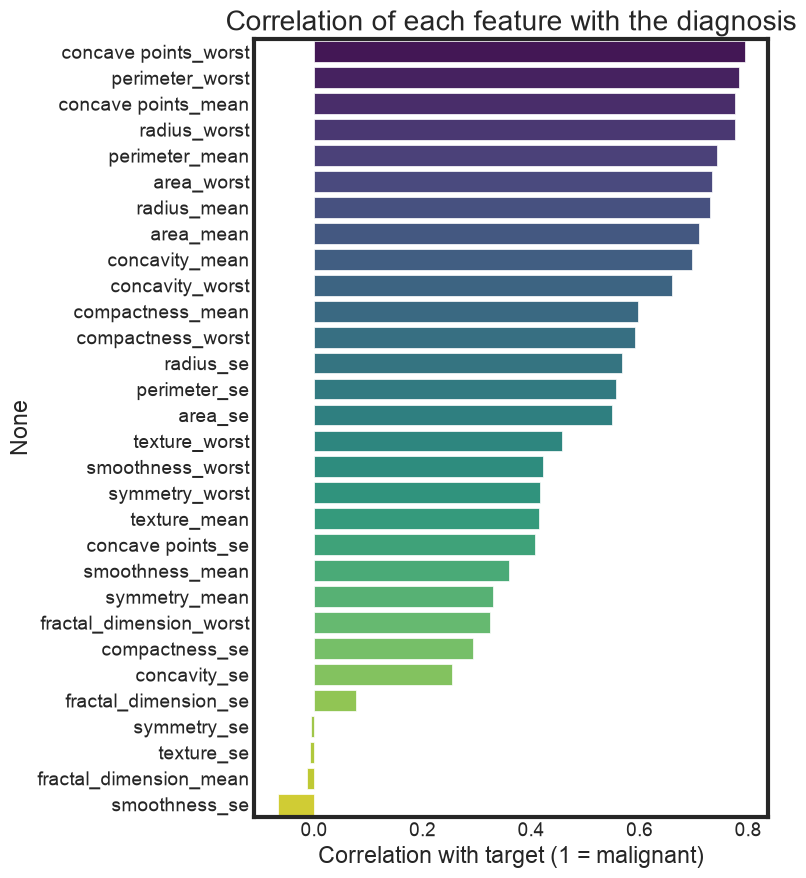

Top 5 features most correlated with a malignant diagnosis:
concave points_worst    0.794
perimeter_worst         0.783
concave points_mean     0.777
radius_worst            0.776
perimeter_mean          0.743
Name: target, dtype: float64


In [17]:
# Which features line up best with the diagnosis itself?

correlation_with_target = (correlation_matrix["target"]
                           .drop("target")
                           .sort_values(ascending=False))

plt.figure(figsize=(8, 9))
sns.barplot(x=correlation_with_target.values, y=correlation_with_target.index, palette="viridis")
plt.title("Correlation of each feature with the diagnosis")
plt.xlabel("Correlation with target (1 = malignant)")
plt.tight_layout()
plt.show()

print("Top 5 features most correlated with a malignant diagnosis:")
print(correlation_with_target.head(5).round(3))

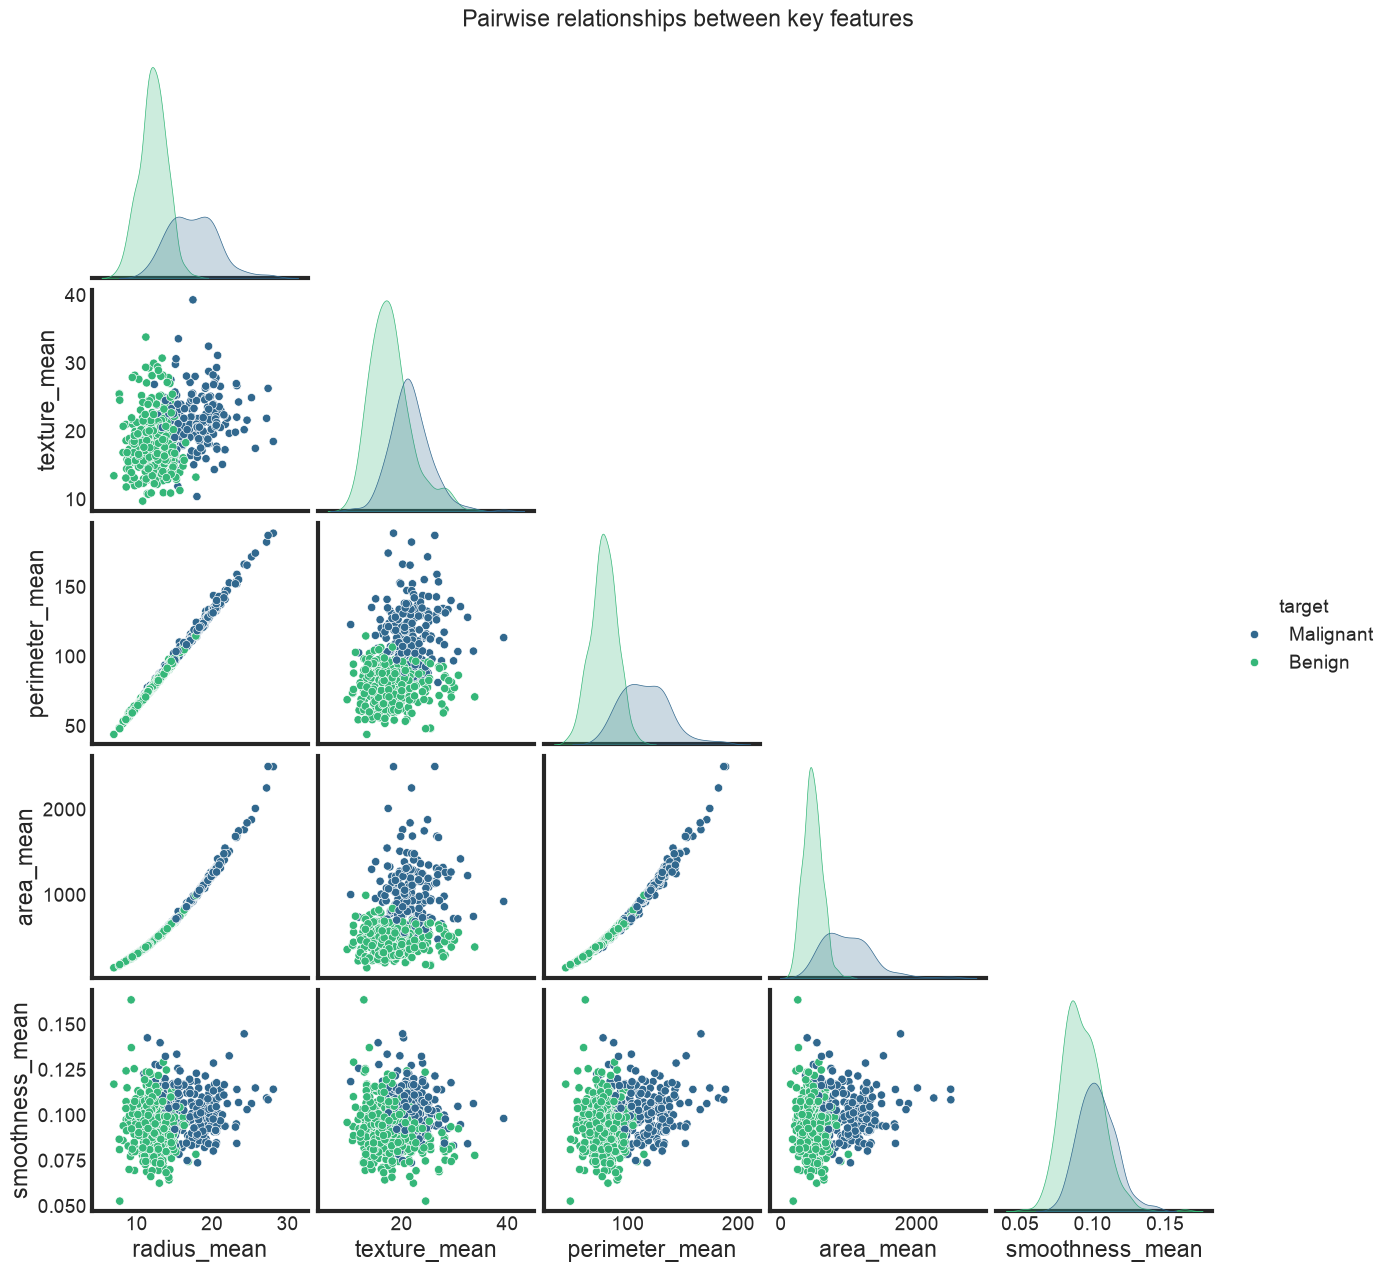

In [18]:
# Pairplot of five headline measurements, coloured by class.
pairplot_columns = ["radius_mean", "texture_mean", "perimeter_mean",
                    "area_mean", "smoothness_mean", "target"]
pairplot_data = cancer_df[pairplot_columns].copy()
pairplot_data["target"] = pairplot_data["target"].map({0: "Benign", 1: "Malignant"})

sns.pairplot(data=pairplot_data, hue="target", palette="viridis", corner=True)
plt.suptitle("Pairwise relationships between key features", y=1.02)
plt.show()

**Interpretation.** Radius, perimeter and area are nearly perfectly correlated, which makes sense because all three describe tumour size. Across all 30 predictors, 21 feature pairs correlate above 0.9, a good argument for using PCA inside our pipelines.

The plot also shows non-linear relationships.This supports keeping non-linear models such as SVM (RBF) and tree-based methods in the comparison.

On the diagonal, benign tumours form a narrow peak at low values for size features, while malignant tumours sit further right with a wider, flatter curve. The classes overlap only in the middle range, where borderline cases are most likely to be misclassified. Texture and smoothness overlap much more, so neither separates the classes well on its own.

The measurements most strongly linked to a malignant diagnosis are `concave points_worst` (0.79), `perimeter_worst` (0.78), `concave points_mean` (0.78) and `radius_worst` (0.78), with `perimeter_mean` just behind at 0.74.

# 3. Feature Engineering

### 3.1 Create derived features

The idea is to capture *shape* and *variability*, not just raw size:

* **compactness ratios** (perimeter squared over area) describe how irregular an outline is,
  independently of how big the tumour is;
* **worst-over-mean ratios** show how much worse the most extreme part of the tumour is than
  its average;
* **mean x standard error products** combine a measurement with how unstable it is.

In [19]:
def add_engineered_features(dataframe):
    """Return a copy of the dataframe with six extra, derived columns."""
    engineered = dataframe.copy()

    # Shape irregularity: for a perfect circle perimeter^2 / area is about 12.57.
    # Higher values mean a more ragged, irregular outline.
    engineered["perimeter_to_area_ratio_mean"] = (
        engineered["perimeter_mean"] ** 2 / engineered["area_mean"])
    engineered["perimeter_to_area_ratio_worst"] = (
        engineered["perimeter_worst"] ** 2 / engineered["area_worst"])

    # How much bigger the worst region is than the average region.
    engineered["radius_worst_over_mean"] = (
        engineered["radius_worst"] / engineered["radius_mean"])
    engineered["texture_worst_over_mean"] = (
        engineered["texture_worst"] / engineered["texture_mean"])

    # Size combined with how variable that size is across the image.
    engineered["radius_mean_times_se"] = (
        engineered["radius_mean"] * engineered["radius_se"])

    # A simple summary of how "dented" the tumour border is.
    engineered["concavity_times_concave_points_mean"] = (
        engineered["concavity_mean"] * engineered["concave points_mean"])

    return engineered

# Build the enriched table and check the new columns separate the classes.
engineered_dataframe = add_engineered_features(cancer_df)
new_feature_names = ["perimeter_to_area_ratio_mean", "perimeter_to_area_ratio_worst",
                     "radius_worst_over_mean", "texture_worst_over_mean",
                     "radius_mean_times_se", "concavity_times_concave_points_mean"]

print("Columns before:", cancer_df.shape[1], "-> after:", engineered_dataframe.shape[1])
print("\nCorrelation of each NEW feature with the diagnosis:")
print(engineered_dataframe[new_feature_names + ["target"]].corr()["target"]
      .drop("target").sort_values(ascending=False).round(3))

Columns before: 31 -> after: 37

Correlation of each NEW feature with the diagnosis:
radius_worst_over_mean                 0.641
concavity_times_concave_points_mean    0.625
radius_mean_times_se                   0.568
perimeter_to_area_ratio_mean           0.506
perimeter_to_area_ratio_worst          0.371
texture_worst_over_mean                0.173
Name: target, dtype: float64


**Interpretation.** The two most useful new features are `radius_worst_over_mean` (0.64)
and `concavity_times_concave_points_mean` (0.63). Neither beats the best original features on
raw correlation, but that is not the point: they express something the original columns
cannot. `radius_worst_over_mean` measures how much worse the tumour's worst region is than
its average, independently of absolute size, so a small but very uneven tumour scores highly.
We will see in Section 8 whether the models actually use them.

# 4. Model Buiding and Model Selection

**Decision Making-Why 70/30 and not 80/20?** With only 569 patients, an 80/20 split would leave about 42 malignant cases in the test set, so a single missed tumour would lower recall. With 70/30 there are about 64, and one miss costs less. Since recall on the malignant class is the metric we care about most, we trade some training data for a more reliable test estimate. Neither choice is wrong here, and the models are tuned with cross-validation on the training set anyway.

## Split

In [20]:
# X holds the predictors, y holds the answer we are trying to predict.
feature_matrix = engineered_dataframe.drop(columns=["target"])
target_vector = engineered_dataframe["target"]

# Stratified split: 70% for training, 30% held back for honest testing.
X_train, X_test, y_train, y_test = train_test_split(
    feature_matrix, target_vector,
    test_size=0.30, random_state=RANDOM_SEED, stratify=target_vector)

print("Training set:", X_train.shape[0], "patients and", X_train.shape[1], "features")
print("Test set:    ", X_test.shape[0], "patients")
print("\nMalignant share in training set:", round(y_train.mean() * 100, 1), "%")
print("Malignant share in test set:    ", round(y_test.mean() * 100, 1), "%")

Training set: 398 patients and 36 features
Test set:     171 patients

Malignant share in training set: 37.2 %
Malignant share in test set:     37.4 %


**Interpretation.** The malignant share is almost identical in both sets (about 37%),
which confirms the stratification worked. The test set is never touched again until we
evaluate the final models.

## Handle Outliers
We cap every feature at its 1st and 99th percentile. The crucial detail is that these
percentile limits are learned from the **training set only** and then applied to the test
set. Learning them from all the data would leak information from the test set into
training.

In [21]:
# Learn the capping limits from the training data only.
lower_limits = X_train.quantile(0.01)
upper_limits = X_train.quantile(0.99)

def cap_extreme_values(dataframe, lower, upper):
    """Clip every column to the limits learned from the training set."""
    return dataframe.clip(lower=lower, upper=upper, axis=1)

X_train_capped = cap_extreme_values(X_train, lower_limits, upper_limits)
X_test_capped = cap_extreme_values(X_test, lower_limits, upper_limits)

# Report how many individual values were actually changed.
values_changed_train = int((X_train_capped.values != X_train.values).sum())
values_changed_test = int((X_test_capped.values != X_test.values).sum())
total_values_train = X_train.shape[0] * X_train.shape[1]

print("Values capped in training set:", values_changed_train,
      "(", round(values_changed_train / total_values_train * 100, 2), "% of all values )")
print("Values capped in test set:    ", values_changed_test)

Values capped in training set: 260 ( 1.81 % of all values )
Values capped in test set:     97


**Interpretation.** Only about 2% of all values were touched, so the data is barely
changed but the most extreme spikes can no longer dominate the scaling step.

## PCA

PCA compresses many correlated columns into a few uncorrelated ones. We saw that radius,
perimeter and area all measure much the same thing, so there is real redundancy to remove.
Here we use PCA first to *look* at the data in two dimensions, then as a tuning step inside
several model pipelines.

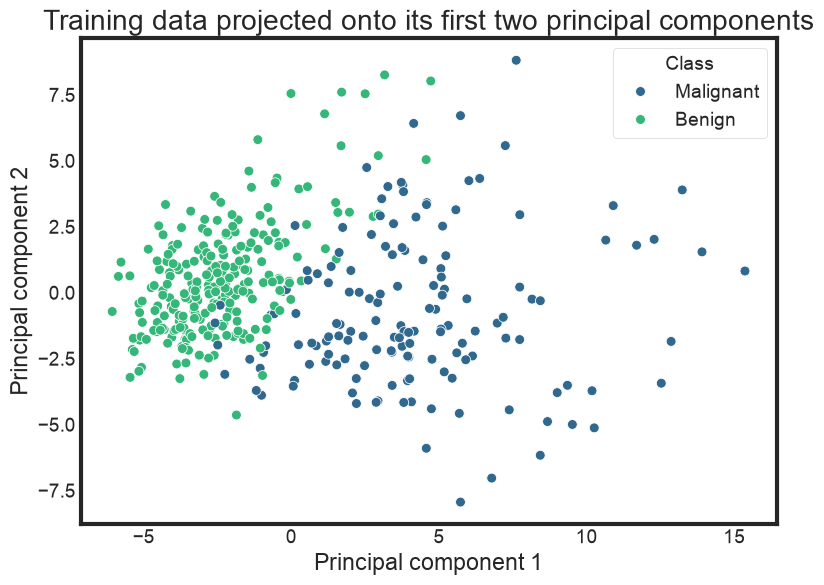

Variance explained by component 1: 46.0 %
Variance explained by component 2: 17.1 %
Two components together explain:   63.2 % of all variation


In [22]:
# Project the training data down to two components purely for visualisation.
visualisation_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2, random_state=RANDOM_SEED))
])
training_data_in_2d = visualisation_pipeline.fit_transform(X_train_capped)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=training_data_in_2d[:, 0], y=training_data_in_2d[:, 1],
                hue=y_train.map({0: "Benign", 1: "Malignant"}), palette="viridis", s=50)
plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
plt.title("Training data projected onto its first two principal components")
plt.legend(title="Class")
plt.show()

explained_variance = visualisation_pipeline.named_steps["pca"].explained_variance_ratio_
print("Variance explained by component 1:", round(explained_variance[0] * 100, 1), "%")
print("Variance explained by component 2:", round(explained_variance[1] * 100, 1), "%")
print("Two components together explain:  ", round(explained_variance.sum() * 100, 1), "% of all variation")

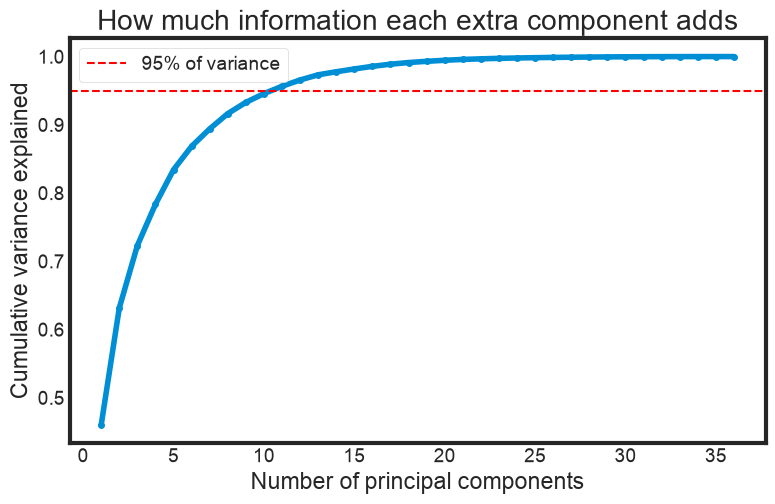

Components needed to keep 95% of the information: 11 out of 36


In [23]:
# How many components do we actually need to keep most of the information?
full_pca_pipeline = Pipeline(steps=[("scaler", StandardScaler()),
                                    ("pca", PCA(random_state=RANDOM_SEED))])
full_pca_pipeline.fit(X_train_capped)
cumulative_variance = np.cumsum(full_pca_pipeline.named_steps["pca"].explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o", markersize=4)
plt.axhline(0.95, color="red", linestyle="--", linewidth=1.5, label="95% of variance")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative variance explained")
plt.title("How much information each extra component adds")
plt.legend()
plt.show()

components_for_95_percent = int(np.argmax(cumulative_variance >= 0.95) + 1)
print("Components needed to keep 95% of the information:", components_for_95_percent,
      "out of", X_train_capped.shape[1])

**Interpretation.** Just two components, holding 63% of the variation, already split the
classes into two visibly different clouds, and 11 components keep 95% of the information from
36 features. This confirms the dataset is highly redundant, which is why PCA is worth tuning
inside the model pipelines below.

## Modeling

Every model below follows the same recipe:

1. A **pipeline** that scales the data (and optionally applies PCA) before fitting.
2. **GridSearchCV** with 5-fold stratified cross-validation to pick the best settings.
3. A **confusion matrix**, a **classification report** and a **ROC-AUC** score on the test set.

Scores are collected in one table so we can compare all the models at the end.

In [24]:
# Shared cross-validation scheme: 5 folds, keeping the class balance in each fold.
cross_validation_scheme = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# This dictionary will collect the results of every model we train.
model_results = {}
fitted_models = {}

def get_positive_class_scores(model, features):
    """Return the score for the malignant class, used for ROC-AUC.

    Most models expose predict_proba; those that do not expose decision_function."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(features)[:, 1]
    return model.decision_function(features)

def evaluate_model(model_name, fitted_model, X_evaluation, y_evaluation, show_plot=True):
    """Score a fitted model on the test set, store the numbers and draw its confusion matrix."""
    predicted_labels = fitted_model.predict(X_evaluation)
    predicted_scores = get_positive_class_scores(fitted_model, X_evaluation)

    results = {
        "Accuracy": accuracy_score(y_evaluation, predicted_labels),
        "Precision": precision_score(y_evaluation, predicted_labels),
        "Recall": recall_score(y_evaluation, predicted_labels),
        "F1": f1_score(y_evaluation, predicted_labels),
        "ROC_AUC": roc_auc_score(y_evaluation, predicted_scores),
    }
    model_results[model_name] = results
    fitted_models[model_name] = fitted_model

    print("=" * 60)
    print("MODEL:", model_name)
    print("=" * 60)
    print(classification_report(y_evaluation, predicted_labels,
                                target_names=["Benign (0)", "Malignant (1)"], digits=3))
    print("ROC-AUC:", round(results["ROC_AUC"], 4))

    if show_plot:
        confusion = confusion_matrix(y_evaluation, predicted_labels)
        plt.figure(figsize=(5, 4))
        sns.heatmap(confusion, annot=True, fmt="d", cmap="viridis", cbar=False,
                    xticklabels=["Benign", "Malignant"], yticklabels=["Benign", "Malignant"])
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title(model_name + " - confusion matrix")
        plt.tight_layout()
        plt.show()
    return results


## 4.1 Logistic Regression (baseline)
It is fast, interpretable and a sensible baseline to beat.

**Personal Notes:**

- **Why to scale and use PCA before logistic regression:** 
Logistic regression requires features to share a similar scale and remain uncorrelated. Scaling ensures fair regularization and prevents large columns like area from dominating PCA. PCA then combines redundant size features into uncorrelated components to keep model coefficients stable, while outliers are handled separately through capping.

- **Why those search ranges in PCA?** 
PCA components range from 2 to 15 because 11 components capture 95% of the variance (calculated above). OJO: el 16 no está incluido -> 15. Y el 2 no es x el target!  ES simplemente un minimo cómodo.

- **What does `np.logspace(-2, 2, 9)` mean?** It creates 9 values between 10⁻² and 10², spaced evenly on a log scale: 0.01, 0.03, 0.1, 0.32, 1, 3.2, 10, 32 and 100. The first two numbers are the exponents (-2 → 0.01, 2 → 100) and the third is how many values to generate.

- **Why `scoring="roc_auc"`?** Cross-validation needs a single metric to pick the winning settings. ROC-AUC does not depend on a decision threshold and is stable with a mild class imbalance like ours (63/37). Accuracy, precision, recall and F1 are calculated later on the test set, once the final model is chosen.

In [25]:
# Pipeline: scale -> compress with PCA -> fit logistic regression.

logistic_regression_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("pca", PCA(random_state=RANDOM_SEED)),
    ("classifier", LogisticRegression(max_iter=5000, random_state=RANDOM_SEED))
])

# Search over how many components to keep and how strong the regularisation should be.
logistic_regression_grid = {
    "pca__n_components": np.arange(2, 16),
    "classifier__C": np.logspace(-2, 2, 9)
}

logistic_regression_search = GridSearchCV(
    logistic_regression_pipeline, param_grid=logistic_regression_grid,
    cv=cross_validation_scheme, scoring="roc_auc", n_jobs=-1)
logistic_regression_search.fit(X_train_capped, y_train)

print("Best settings:", logistic_regression_search.best_params_)
print("Cross-validated ROC-AUC on training data:", round(logistic_regression_search.best_score_, 4))

Best settings: {'classifier__C': np.float64(0.31622776601683794), 'pca__n_components': np.int64(15)}
Cross-validated ROC-AUC on training data: 0.9966


**Interpretation.** The best model uses 15 components and moderate regularisation (C ≈ 0.32), and reaches a cross-validated ROC-AUC of 0.9966 on the training data. 

MODEL: Logistic Regression
               precision    recall  f1-score   support

   Benign (0)      0.964     1.000     0.982       107
Malignant (1)      1.000     0.938     0.968        64

     accuracy                          0.977       171
    macro avg      0.982     0.969     0.975       171
 weighted avg      0.977     0.977     0.976       171

ROC-AUC: 0.999


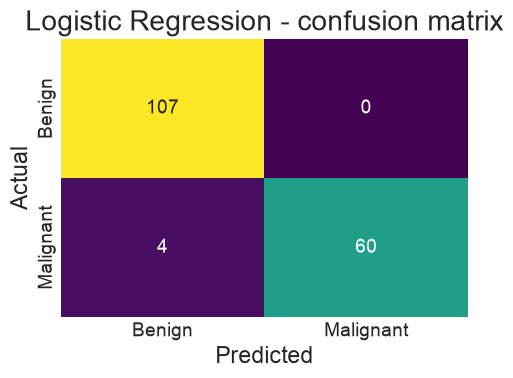

{'Accuracy': 0.9766081871345029,
 'Precision': 1.0,
 'Recall': 0.9375,
 'F1': 0.967741935483871,
 'ROC_AUC': 0.9989778037383178}

In [26]:
# Score the tuned logistic regression on the untouched test set.
evaluate_model("Logistic Regression", logistic_regression_search, X_test_capped, y_test)

**Interpretation.** Compressing the 36 features into 15 principal components is enough for logistic regression to separate the classes almost perfectly (cross-validated ROC-AUC of 0.9966). The few patients it gets wrong are likely those near the boundary between the two classes.

## 4.2 Decision Tree
A single tree splits the data with a series of yes/no questions. It is easy to read but
prone to overfitting, which is why we limit its depth.

In [27]:
# Pipeline with a single decision tree. Scaling is not strictly needed for trees,
# but keeping it makes all pipelines consistent.
decision_tree_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("classifier", DecisionTreeClassifier(random_state=RANDOM_SEED))
])

# Control the size of the tree to stop it memorising the training data.
decision_tree_grid = {
    "classifier__max_depth": [2, 3, 4, 5, 6, None],
    "classifier__min_samples_leaf": [1, 3, 5, 10],
    "classifier__criterion": ["gini", "entropy"]
}

decision_tree_search = GridSearchCV(decision_tree_pipeline, param_grid=decision_tree_grid,
                                    cv=cross_validation_scheme, scoring="roc_auc", n_jobs=-1)
decision_tree_search.fit(X_train_capped, y_train)

print("Best settings:", decision_tree_search.best_params_)
print("Cross-validated ROC-AUC on training data:", round(decision_tree_search.best_score_, 4))

Best settings: {'classifier__criterion': 'entropy', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 10}
Cross-validated ROC-AUC on training data: 0.9582


In [28]:
# Pipeline with a single decision tree. Scaling is not strictly needed for trees,
# but keeping it makes all pipelines consistent.
decision_tree_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("classifier", DecisionTreeClassifier(random_state=RANDOM_SEED))
])

# Control the size of the tree to stop it memorising the training data.
decision_tree_grid = {
    "classifier__max_depth": [2, 3, 4, 5, 6, None],
    "classifier__min_samples_leaf": [1, 3, 5, 10],
    "classifier__criterion": ["gini", "entropy"]
}

decision_tree_search = GridSearchCV(decision_tree_pipeline, param_grid=decision_tree_grid,
                                    cv=cross_validation_scheme, scoring="roc_auc", n_jobs=-1)
decision_tree_search.fit(X_train_capped, y_train)

print("Best settings:", decision_tree_search.best_params_)
print("Cross-validated ROC-AUC on training data:", round(decision_tree_search.best_score_, 4))

Best settings: {'classifier__criterion': 'entropy', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 10}
Cross-validated ROC-AUC on training data: 0.9582


MODEL: Decision Tree
               precision    recall  f1-score   support

   Benign (0)      0.938     0.981     0.959       107
Malignant (1)      0.966     0.891     0.927        64

     accuracy                          0.947       171
    macro avg      0.952     0.936     0.943       171
 weighted avg      0.948     0.947     0.947       171

ROC-AUC: 0.9854


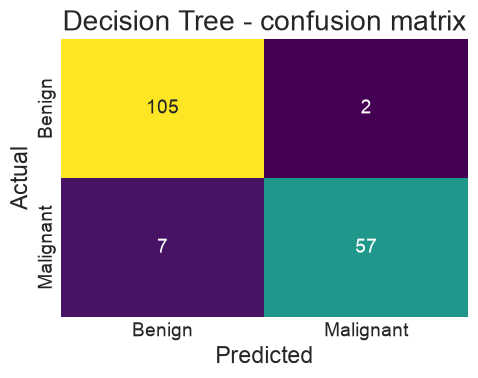

{'Accuracy': 0.9473684210526315,
 'Precision': 0.9661016949152542,
 'Recall': 0.890625,
 'F1': 0.926829268292683,
 'ROC_AUC': 0.9853971962616822}

In [29]:
# Score the tuned decision tree on the test set.
evaluate_model("Decision Tree", decision_tree_search, X_test_capped, y_test)

**Interpretation.** ROC-AUC is a bit lower than before (0.985) and
misses about 11% of malignant tumours (7/64=0,109). 

This is exactly the weakness that ensembles fix.

## 4.3 Random Forest
A random forest averages hundreds of different decision trees. Each tree sees a random
sample of rows and columns, so their individual mistakes tend to cancel out.

In [30]:
# Pipeline with a random forest of many trees.
random_forest_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("classifier", RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1))
])

# Tune the number of trees, their depth and how many features each split may consider.
random_forest_grid = {
    "classifier__n_estimators": [300, 600],
    "classifier__max_depth": [4, 8, None],
    "classifier__max_features": ["sqrt", 0.3],
    "classifier__min_samples_leaf": [1, 2]
}

random_forest_search = GridSearchCV(random_forest_pipeline, param_grid=random_forest_grid,
                                    cv=cross_validation_scheme, scoring="roc_auc", n_jobs=-1)
random_forest_search.fit(X_train_capped, y_train)

print("Best settings:", random_forest_search.best_params_)
print("Cross-validated ROC-AUC on training data:", round(random_forest_search.best_score_, 4))

Best settings: {'classifier__max_depth': 8, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 600}
Cross-validated ROC-AUC on training data: 0.9887


MODEL: Random Forest
               precision    recall  f1-score   support

   Benign (0)      0.955     1.000     0.977       107
Malignant (1)      1.000     0.922     0.959        64

     accuracy                          0.971       171
    macro avg      0.978     0.961     0.968       171
 weighted avg      0.972     0.971     0.970       171

ROC-AUC: 0.9974


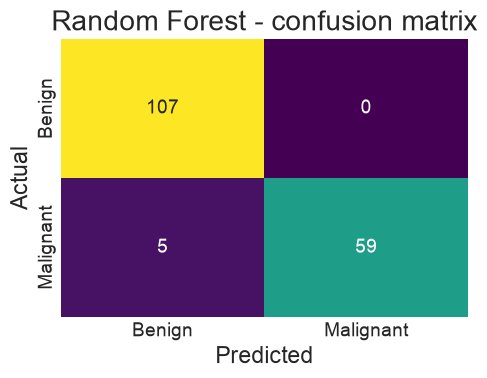

{'Accuracy': 0.9707602339181286,
 'Precision': 1.0,
 'Recall': 0.921875,
 'F1': 0.959349593495935,
 'ROC_AUC': 0.9973714953271028}

In [31]:
# Score the tuned random forest on the test set.
evaluate_model("Random Forest", random_forest_search, X_test_capped, y_test)

**Interpretation.** 
ROC-AUC rises from 0.985 to 0.997 and recall from 89% to 92% compared with the single tree.
Averaging 600 trees removes most of the instability we saw above. Every malignancy alert it
raises is correct (precision 1.00).

## 4.4 K-Nearest Neighbours (KNN)

KNN classifies a patient by looking at the most similar patients in the training set. It
depends entirely on distance, so scaling is essential here.

In [32]:
# Pipeline: scale -> PCA (distances behave better in fewer dimensions) -> KNN.
knn_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("pca", PCA(random_state=RANDOM_SEED)),
    ("classifier", KNeighborsClassifier())
])

# Tune how many components to keep, how many neighbours to consult and how to weight them.
knn_grid = {
    "pca__n_components": np.arange(2, 16),
    # Odd values from 3 to 25 (odd avoids tied votes between the two classes). 2: step 
    "classifier__n_neighbors": np.arange(3, 26, 2),
    "classifier__weights": ["uniform", "distance"]
}

knn_search = GridSearchCV(knn_pipeline, param_grid=knn_grid,
                          cv=cross_validation_scheme, scoring="roc_auc", n_jobs=-1)
knn_search.fit(X_train_capped, y_train)

print("Best settings:", knn_search.best_params_)
print("Cross-validated ROC-AUC on training data:", round(knn_search.best_score_, 4))

Best settings: {'classifier__n_neighbors': np.int64(25), 'classifier__weights': 'distance', 'pca__n_components': np.int64(13)}
Cross-validated ROC-AUC on training data: 0.9923


MODEL: KNN
               precision    recall  f1-score   support

   Benign (0)      0.922     1.000     0.960       107
Malignant (1)      1.000     0.859     0.924        64

     accuracy                          0.947       171
    macro avg      0.961     0.930     0.942       171
 weighted avg      0.951     0.947     0.946       171

ROC-AUC: 0.9978


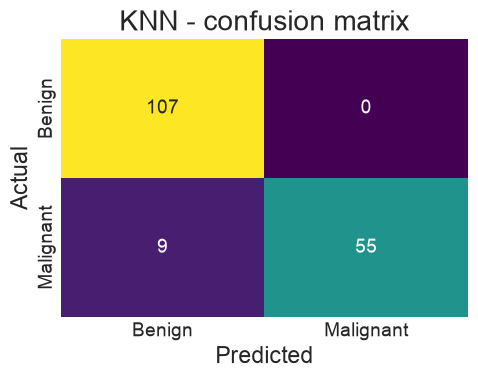

{'Accuracy': 0.9473684210526315,
 'Precision': 1.0,
 'Recall': 0.859375,
 'F1': 0.9243697478991597,
 'ROC_AUC': 0.9978095794392524}

In [33]:
# Score the tuned KNN model on the test set.
evaluate_model("KNN", knn_search, X_test_capped, y_test)

**Interpretation.** KNN reaches a ROC-AUC of 0.998, so it ranks malignant patients above benign ones almost perfectly. However, at the default 0.5 cut-off it misses 9 of the 64 malignant tumours (recall 0.86), while raising no false alarms (precision 1.00, no benign patient flagged). In other words, the model is very cautious about calling a tumour malignant. A high ROC-AUC does not guarantee a high recall at a fixed threshold, so the other metrics need to be checked too.

## 4.5 Gaussian Naive Bayes

Naive Bayes assumes each feature follows a normal distribution and that features are
independent. Neither assumption really holds here, but PCA helps because the components it
produces are uncorrelated by construction.

In [34]:
# Pipeline: scale -> PCA (makes the 'independent features' assumption more reasonable) -> Naive Bayes.
naive_bayes_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("pca", PCA(random_state=RANDOM_SEED)),
    ("classifier", GaussianNB())
])

naive_bayes_grid = {"pca__n_components": np.arange(2, 21)}

naive_bayes_search = GridSearchCV(naive_bayes_pipeline, param_grid=naive_bayes_grid,
                                  cv=cross_validation_scheme, scoring="roc_auc", n_jobs=-1)
naive_bayes_search.fit(X_train_capped, y_train)

print("Best settings:", naive_bayes_search.best_params_)
print("Cross-validated ROC-AUC on training data:", round(naive_bayes_search.best_score_, 4))

Best settings: {'pca__n_components': np.int64(5)}
Cross-validated ROC-AUC on training data: 0.9786


MODEL: Gaussian Naive Bayes
               precision    recall  f1-score   support

   Benign (0)      0.913     0.981     0.946       107
Malignant (1)      0.964     0.844     0.900        64

     accuracy                          0.930       171
    macro avg      0.939     0.913     0.923       171
 weighted avg      0.932     0.930     0.929       171

ROC-AUC: 0.9864


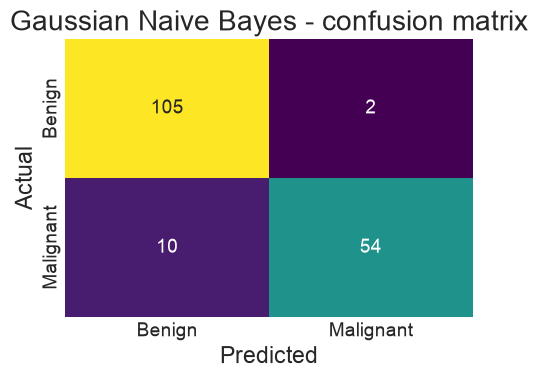

{'Accuracy': 0.9298245614035088,
 'Precision': 0.9642857142857143,
 'Recall': 0.84375,
 'F1': 0.9,
 'ROC_AUC': 0.9864193925233644}

In [35]:
# Score the tuned Naive Bayes model on the test set.
evaluate_model("Gaussian Naive Bayes", naive_bayes_search, X_test_capped, y_test)

**Interpretation.** Naive Bayes has the lowest accuracy (93.0%) and the lowest recall
(84.4%) so far.Its independence assumption is a limitation, because radius, perimeter and area are strongly linked. PCA helps by making the components uncorrelated, and the grid search kept only 5 of them.

## 4.6 SVM
An SVM draws the widest possible boundary between the two classes. With an RBF kernel that
boundary can be curved, which suits data like this.

In [36]:
# Pipeline: scale -> PCA -> support vector classifier.
# probability=True lets us produce probabilities for the ROC-AUC calculation.
support_vector_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("pca", PCA(random_state=RANDOM_SEED)),
    ("classifier", SVC(kernel="rbf", probability=True, random_state=RANDOM_SEED))
])

# C controls how much we penalise mistakes; gamma controls how curved the boundary is.
support_vector_grid = {
    "pca__n_components": [5, 10, 15],
    "classifier__C": np.logspace(-1, 3, 6),
    "classifier__gamma": np.logspace(-4, 0, 6)
}

support_vector_search = GridSearchCV(support_vector_pipeline, param_grid=support_vector_grid,
                                     cv=cross_validation_scheme, scoring="roc_auc", n_jobs=-1)
support_vector_search.fit(X_train_capped, y_train)

print("Best settings:", support_vector_search.best_params_)
print("Cross-validated ROC-AUC on training data:", round(support_vector_search.best_score_, 4))

Best settings: {'classifier__C': np.float64(158.48931924611142), 'classifier__gamma': np.float64(0.000630957344480193), 'pca__n_components': 15}
Cross-validated ROC-AUC on training data: 0.9976


MODEL: Support Vector Machine
               precision    recall  f1-score   support

   Benign (0)      0.964     0.991     0.977       107
Malignant (1)      0.984     0.938     0.960        64

     accuracy                          0.971       171
    macro avg      0.974     0.964     0.968       171
 weighted avg      0.971     0.971     0.971       171

ROC-AUC: 0.9974


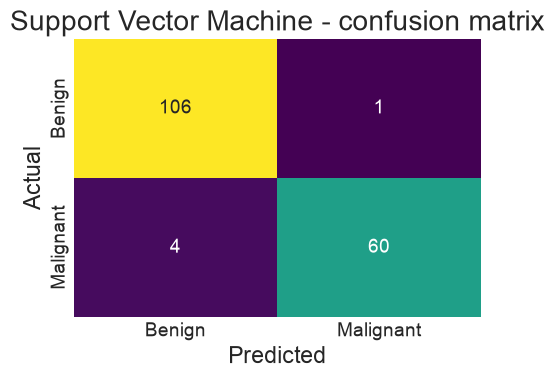

{'Accuracy': 0.9707602339181286,
 'Precision': 0.9836065573770492,
 'Recall': 0.9375,
 'F1': 0.96,
 'ROC_AUC': 0.9973714953271028}

In [37]:
# Score the tuned SVM on the test set.
evaluate_model("Support Vector Machine", support_vector_search, X_test_capped, y_test)

**Interpretation.** The SVM reaches a ROC-AUC of 0.997 and a recall of 93.8% (it misses 4 of the 64 malignant tumours). It raises 1 false alarm (precision 0.98). Its recall matches logistic regression's, so the curved RBF boundary brings no clear gain over a straight line here.

## 4.7 XBoost (gradient Boosting)
Boosting builds trees one after another, each one focusing on the patients the previous
trees got wrong. It is usually the strongest option for small tabular datasets like this.

In [38]:
# Pipeline with gradient-boosted trees. No PCA here: boosting benefits from the
# original features, and keeping them lets us read off feature importance later.
xgboost_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("classifier", XGBClassifier(n_estimators=300, eval_metric="logloss",
                                 random_state=RANDOM_SEED, n_jobs=-1))
])

# Tune the learning rate, tree depth and regularisation strength.
xgboost_grid = {
    "classifier__learning_rate": [0.01, 0.05, 0.1],
    "classifier__max_depth": [2, 3, 4],
    "classifier__subsample": [0.8, 1.0],
    "classifier__reg_lambda": [0.1, 1.0, 10.0]
}

xgboost_search = GridSearchCV(xgboost_pipeline, param_grid=xgboost_grid,
                              cv=cross_validation_scheme, scoring="roc_auc", n_jobs=-1)
xgboost_search.fit(X_train_capped, y_train)

print("Best settings:", xgboost_search.best_params_)
print("Cross-validated ROC-AUC on training data:", round(xgboost_search.best_score_, 4))

Best settings: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 2, 'classifier__reg_lambda': 0.1, 'classifier__subsample': 0.8}
Cross-validated ROC-AUC on training data: 0.9939


MODEL: XGBoost
               precision    recall  f1-score   support

   Benign (0)      0.964     1.000     0.982       107
Malignant (1)      1.000     0.938     0.968        64

     accuracy                          0.977       171
    macro avg      0.982     0.969     0.975       171
 weighted avg      0.977     0.977     0.976       171

ROC-AUC: 0.9987


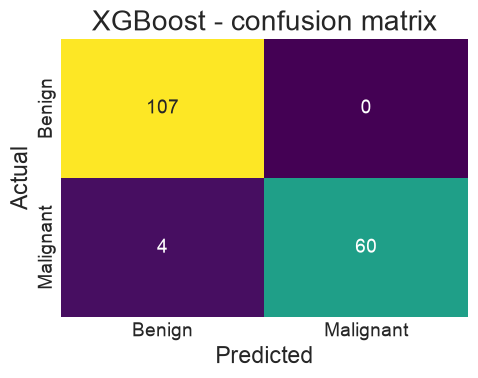

{'Accuracy': 0.9766081871345029,
 'Precision': 1.0,
 'Recall': 0.9375,
 'F1': 0.967741935483871,
 'ROC_AUC': 0.9986857476635513}

In [39]:
# Score the tuned XGBoost model on the test set.
evaluate_model("XGBoost", xgboost_search, X_test_capped, y_test)

**Interpretation.** XGBoost classifies 167 of the 171 test patients correctly (accuracy 97.7%). It catches 60 of the 64 malignant tumours (recall 93.75%), misses 4, and raises no false alarms (precision 1.00). Its ROC-AUC is 0.9987.

The grid search chose very shallow trees (`max_depth` = 2): XGBoost builds many small trees one after another, each correcting the errors of the previous ones, and with only 398 training patients small trees are less likely to memorise the training data than deep ones.

## 4.8 Stacking ensemble
Stacking feeds the predictions of all seven models into one final model, which learns how much weight to give each of them.

We use **cross-validated predictions**, so each prediction comes from a model that did not see that patient during training.

In [40]:
from sklearn.model_selection import cross_val_predict

# Collect the seven tuned pipelines, each refitted on the full training set.
base_model_pipelines = {
    "Logistic Regression": logistic_regression_search.best_estimator_,
    "Decision Tree": decision_tree_search.best_estimator_,
    "Random Forest": random_forest_search.best_estimator_,
    "KNN": knn_search.best_estimator_,
    "Gaussian Naive Bayes": naive_bayes_search.best_estimator_,
    "Support Vector Machine": support_vector_search.best_estimator_,
    "XGBoost": xgboost_search.best_estimator_,
}

# Build the training input for the final model using out-of-fold probabilities.
# 'Out-of-fold' means each probability comes from a model that never saw that patient.
stacking_training_features = pd.DataFrame({
    model_name: cross_val_predict(model, X_train_capped, y_train,
                                  cv=cross_validation_scheme, method="predict_proba")[:, 1]
    for model_name, model in base_model_pipelines.items()
})

print("Shape of the stacking input:", stacking_training_features.shape)
stacking_training_features.head().round(3)

Shape of the stacking input: (398, 7)


,Logistic Regression,Decision Tree,Random Forest,KNN,Gaussian Naive Bayes,Support Vector Machine,XGBoost
0,1.000,1.0,0.983,1.000,1.000,1.000,1.000
1,0.866,1.0,0.867,0.614,0.708,0.734,0.889
2,0.005,0.0,0.002,0.000,0.027,0.014,0.000
3,0.122,1.0,0.747,0.405,0.999,0.408,0.992
4,0.266,0.2,0.407,0.179,0.342,0.191,0.180


**Personal Note on how to read this table.** Each row is one training patient and each column is one of the seven models. The value is the probability of malignant given by that model (0 = surely benign, 1 = surely malignant). Every prediction is cross-validated, so it comes from a model that did not see that patient. Row 0 is a clear malignant case (all models near 1) and row 2 a clear benign one (all near 0), while in row 3 the models disagree (from 0.12 to 1.0). These 7 columns are the input of the final model, which learns how much to trust each one.

In [41]:
# The final model is a small logistic regression that weighs the seven opinions.
stacking_grid = {"C": np.logspace(-2, 2, 9)}
stacking_search = GridSearchCV(
    LogisticRegression(max_iter=5000, random_state=RANDOM_SEED),
    param_grid=stacking_grid, cv=cross_validation_scheme, scoring="roc_auc", n_jobs=-1)
stacking_search.fit(stacking_training_features, y_train)

print("Best settings:", stacking_search.best_params_)
print("Cross-validated ROC-AUC of the stack:", round(stacking_search.best_score_, 4))

# Show how much weight the final model gives to each base model.
stacking_weights = pd.Series(stacking_search.best_estimator_.coef_[0],
                             index=stacking_training_features.columns).sort_values(ascending=False)
print("\nWeight given to each base model (higher = more trusted):")
print(stacking_weights.round(3))

Best settings: {'C': np.float64(31.622776601683793)}
Cross-validated ROC-AUC of the stack: 0.997

Weight given to each base model (higher = more trusted):
Support Vector Machine    7.600
XGBoost                   4.199
Logistic Regression       3.537
Gaussian Naive Bayes      2.213
KNN                       0.420
Decision Tree            -2.264
Random Forest            -2.579
dtype: float64


               precision    recall  f1-score   support

   Benign (0)      0.973     1.000     0.986       107
Malignant (1)      1.000     0.953     0.976        64

     accuracy                          0.982       171
    macro avg      0.986     0.977     0.981       171
 weighted avg      0.983     0.982     0.982       171

ROC-AUC: 0.9978


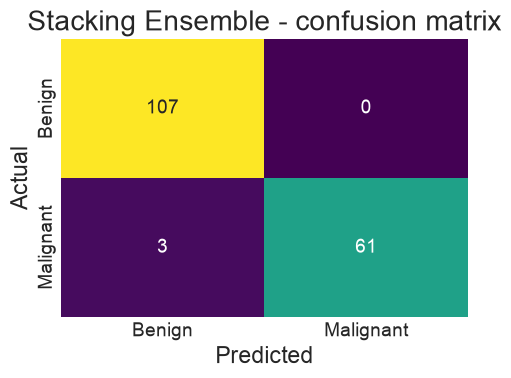

In [42]:
# Get each base model's probability of malignant for the test patients (same seven columns as before).
# Then the final model combines them using the weights it learned on the training data.

stacking_test_features = pd.DataFrame({
    model_name: model.predict_proba(X_test_capped)[:, 1]
    for model_name, model in base_model_pipelines.items()
})

stacked_predicted_labels = stacking_search.predict(stacking_test_features)
stacked_predicted_scores = stacking_search.predict_proba(stacking_test_features)[:, 1]

model_results["Stacking Ensemble"] = {
    "Accuracy": accuracy_score(y_test, stacked_predicted_labels),
    "Precision": precision_score(y_test, stacked_predicted_labels),
    "Recall": recall_score(y_test, stacked_predicted_labels),
    "F1": f1_score(y_test, stacked_predicted_labels),
    "ROC_AUC": roc_auc_score(y_test, stacked_predicted_scores),
}

print(classification_report(y_test, stacked_predicted_labels,
                            target_names=["Benign (0)", "Malignant (1)"], digits=3))
print("ROC-AUC:", round(model_results["Stacking Ensemble"]["ROC_AUC"], 4))

confusion = confusion_matrix(y_test, stacked_predicted_labels)
plt.figure(figsize=(5, 4))
sns.heatmap(confusion, annot=True, fmt="d", cmap="viridis", cbar=False,
            xticklabels=["Benign", "Malignant"], yticklabels=["Benign", "Malignant"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Stacking Ensemble - confusion matrix")
plt.tight_layout()
plt.show()

**Interpretation.** The stack classifies has an accuracy of 98.2%. It misses 3 malignant tumours (recall 95.3%) and raises no false alarms. That is one miss fewer than XGBoost, while its ROC-AUC (0.9978) is slightly below XGBoost's (0.9987). Both differences are a single patient, which on a test set of 171 patients is within noise.

The final model relies mostly on the SVM, logistic regression and XGBoost, and gives the decision tree and random forest negative weights. A negative weight does not mean those models are useless: the final model uses them as a correction, lowering its score when they are more confident than the others.

# 5. Evaluation: comparing every model 

In [43]:
# Put every model's test-set scores into one sorted table.
results_table = pd.DataFrame(model_results).T
results_table = results_table.sort_values("ROC_AUC", ascending=False).round(4)
results_table

,Accuracy,Precision,Recall,F1,ROC_AUC
Logistic Regression,0.9766,1.0000,0.9375,0.9677,0.9990
XGBoost,0.9766,1.0000,0.9375,0.9677,0.9987
KNN,0.9474,1.0000,0.8594,0.9244,0.9978
Stacking Ensemble,0.9825,1.0000,0.9531,0.9760,0.9978
Support Vector Machine,0.9708,0.9836,0.9375,0.9600,0.9974
Random Forest,0.9708,1.0000,0.9219,0.9593,0.9974
Gaussian Naive Bayes,0.9298,0.9643,0.8438,0.9000,0.9864
Decision Tree,0.9474,0.9661,0.8906,0.9268,0.9854


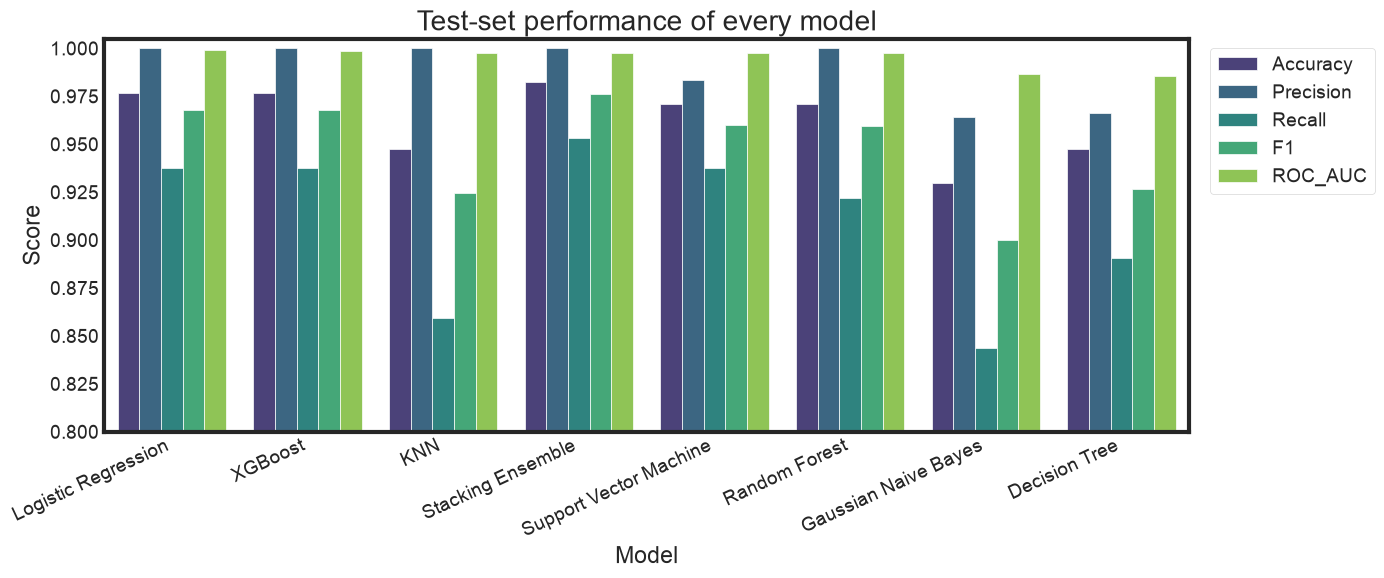

In [44]:
# Same numbers as a grouped bar chart, which makes the differences easier to see.
plot_table = results_table.reset_index().rename(columns={"index": "Model"})
melted_results = plot_table.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(14, 6))
sns.barplot(x="Model", y="Score", hue="Metric", data=melted_results, palette="viridis")
plt.xticks(rotation=25, ha="right")
plt.ylim(0.80, 1.005)
plt.title("Test-set performance of every model")
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Interpretation.**
- ROC-AUC : All models separate the two classes very well (ROC-AUC between 0.985 and 0.999), but six of the eight are within 0.002 of each other, so ROC-AUC alone cannot tell us which one is best.
- Precision is 1.00 for five models (no false alarms), so the real differences are in recall, which goes from 84% (Naive Bayes) to 95% (Stacking).
- Logistic regression, the simplest model, ties XGBoost in accuracy and recall (97.7% and 93.75%), so a more complex model does not clearly help here.
- KNN has a high ROC-AUC but the second-lowest recall (85.9%): it ranks patients well, but at the 0.5 cut-off it misses too many malignant tumours.
- Stacking has the highest accuracy (98.2%) and recall (95.3%), but only one patient better than logistic regression and XGBoost, which is within noise for 171 test patients.

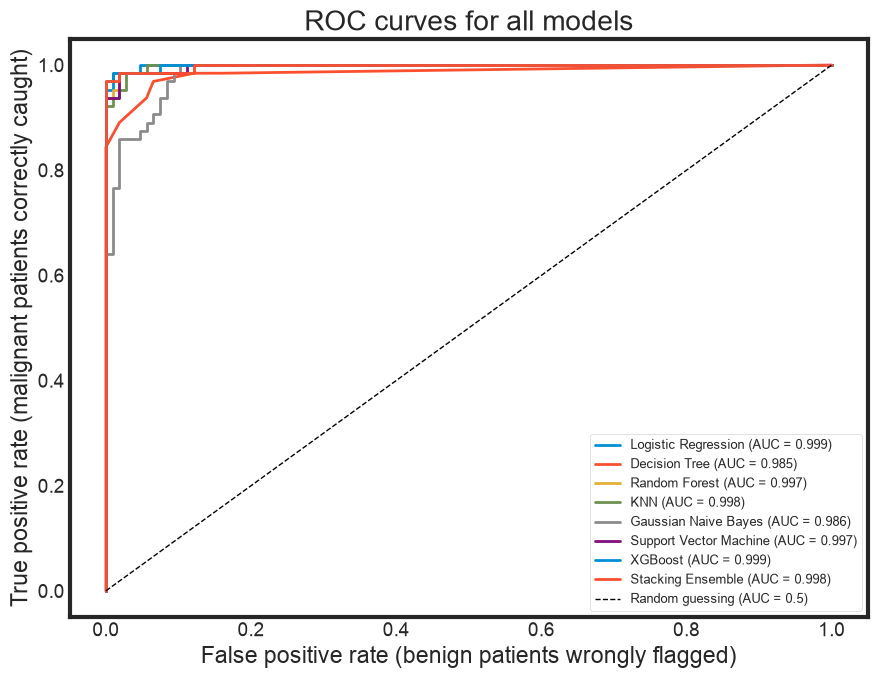

In [45]:
# Overlay the ROC curves of all the base models on a single plot.
plt.figure(figsize=(9, 7))

for model_name, model in base_model_pipelines.items():
    predicted_scores = model.predict_proba(X_test_capped)[:, 1]
    false_positive_rate, true_positive_rate, _ = roc_curve(y_test, predicted_scores)
    area_under_curve = roc_auc_score(y_test, predicted_scores)
    plt.plot(false_positive_rate, true_positive_rate, linewidth=2,
             label=model_name + " (AUC = " + str(round(area_under_curve, 3)) + ")")

# The stacking ensemble too.
false_positive_rate, true_positive_rate, _ = roc_curve(y_test, stacked_predicted_scores)
plt.plot(false_positive_rate, true_positive_rate, linewidth=2, linestyle="-",
         label="Stacking Ensemble (AUC = " +
               str(round(model_results['Stacking Ensemble']['ROC_AUC'], 3)) + ")")

# A diagonal line showing what random guessing would look like.
plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random guessing (AUC = 0.5)")
plt.xlabel("False positive rate (benign patients wrongly flagged)")
plt.ylabel("True positive rate (malignant patients correctly caught)")
plt.title("ROC curves for all models")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

**Interpretation.** Most curves hug the top-left corner, meaning they catch nearly all malignant tumours before raising many false alarms. Only Naive Bayes and the Decision Tree are visibly lower, which matches their lower AUCs (0.986 and 0.985).

In [46]:
# Identify the best model by ROC-AUC and describe its mistakes in plain language.
best_model_name = results_table["ROC_AUC"].idxmax()
best_model_scores = results_table.loc[best_model_name]

if best_model_name == "Stacking Ensemble":
    best_predicted_labels = stacked_predicted_labels
else:
    best_predicted_labels = base_model_pipelines[best_model_name].predict(X_test_capped)

true_negatives, false_positives, false_negatives, true_positives = confusion_matrix(
    y_test, best_predicted_labels).ravel()

print("BEST MODEL BY ROC-AUC:", best_model_name)
print("-" * 55)
print("Accuracy :", round(best_model_scores["Accuracy"] * 100, 2), "%")
print("Recall   :", round(best_model_scores["Recall"] * 100, 2), "% of malignant tumours were caught")
print("Precision:", round(best_model_scores["Precision"] * 100, 2), "% of malignancy alerts were correct")
print("ROC-AUC  :", round(best_model_scores["ROC_AUC"], 4))
print()
print("On the", len(y_test), "held-out patients:")
print("  correctly identified as malignant (true positives):", true_positives)
print("  correctly identified as benign (true negatives):   ", true_negatives)
print("  benign patients wrongly flagged (false positives): ", false_positives,
      "-> unnecessary follow-up tests")
print("  malignant tumours MISSED (false negatives):        ", false_negatives,
      "-> the most serious kind of error")

BEST MODEL BY ROC-AUC: Logistic Regression
-------------------------------------------------------
Accuracy : 97.66 %
Recall   : 93.75 % of malignant tumours were caught
Precision: 100.0 % of malignancy alerts were correct
ROC-AUC  : 0.999

On the 171 held-out patients:
  correctly identified as malignant (true positives): 60
  correctly identified as benign (true negatives):    107
  benign patients wrongly flagged (false positives):  0 -> unnecessary follow-up tests
  malignant tumours MISSED (false negatives):         4 -> the most serious kind of error


**Choosing the best model.** ROC-AUC picks logistic regression (0.9990), but it does not depend on a threshold, so it says nothing about how many cancers are missed at the default 0.5 cut-off. If recall matters most, the stacking ensemble is the best choice: it misses 3 malignant tumours, against 4 for logistic regression, XGBoost and SVM, with no false alarms. The difference is a single patient, so it is not conclusive.

# 6. Feature Importance

## RF built-in importance

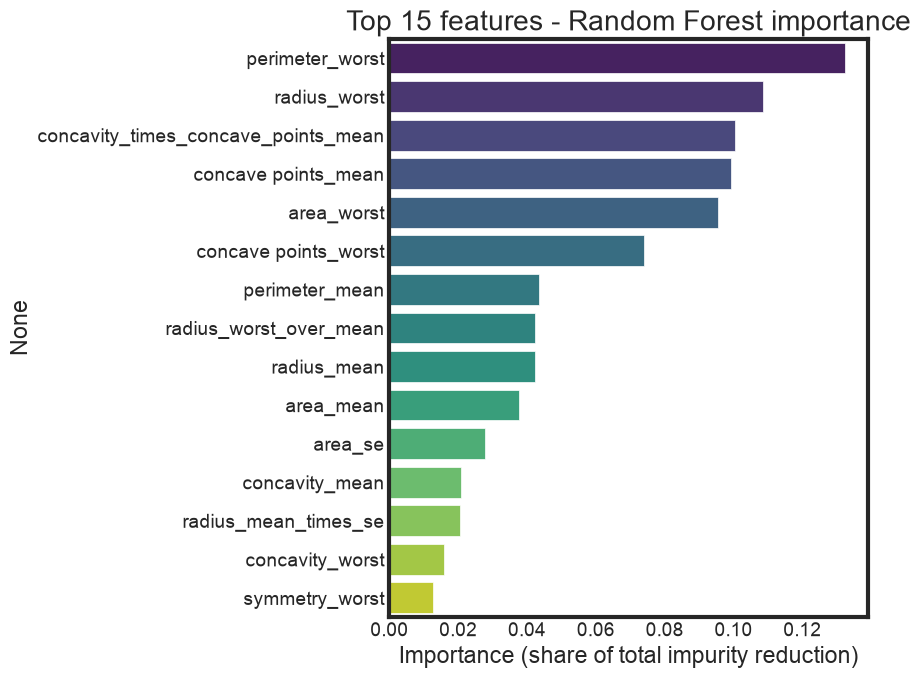

Top 10 features:
perimeter_worst                        0.1324
radius_worst                           0.1085
concavity_times_concave_points_mean    0.1005
concave points_mean                    0.0992
area_worst                             0.0956
concave points_worst                   0.0739
perimeter_mean                         0.0434
radius_worst_over_mean                 0.0425
radius_mean                            0.0423
area_mean                              0.0378
dtype: float64


In [50]:
# Pull the importance scores straight out of the fitted random forest.
random_forest_classifier = random_forest_search.best_estimator_.named_steps["classifier"]
feature_importance_scores = pd.Series(random_forest_classifier.feature_importances_,
                                      index=X_train_capped.columns).sort_values(ascending=False)

top_15_features = feature_importance_scores.head(15)

plt.figure(figsize=(9, 7))
sns.barplot(x=top_15_features.values, y=top_15_features.index, palette="viridis")
plt.title("Top 15 features - Random Forest importance")
plt.xlabel("Importance (share of total impurity reduction)")
plt.tight_layout()
plt.show()

print("Top 10 features:")
print(top_15_features.head(10).round(4))

## Permutation Importance
Permutation importance works differently: it shuffles one feature at a time and measures how
much the model's score drops. It is slower but more trustworthy, because it measures effect
on real predictions rather than on internal splitting decisions.

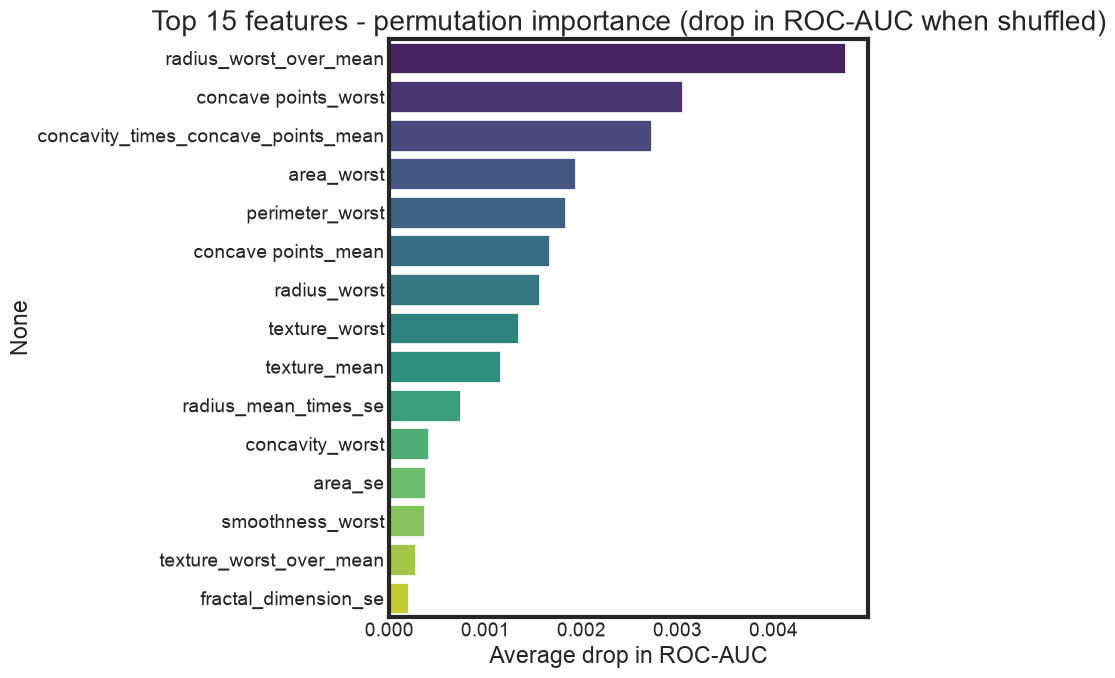

Top 10 features by permutation importance:
radius_worst_over_mean                 0.0047
concave points_worst                   0.0031
concavity_times_concave_points_mean    0.0027
area_worst                             0.0019
perimeter_worst                        0.0018
concave points_mean                    0.0017
radius_worst                           0.0016
texture_worst                          0.0013
texture_mean                           0.0012
radius_mean_times_se                   0.0007
dtype: float64


In [51]:
# Shuffle each feature 20 times and record how far the ROC-AUC falls.
permutation_results = permutation_importance(
    random_forest_search.best_estimator_, X_test_capped, y_test,
    n_repeats=20, random_state=RANDOM_SEED, scoring="roc_auc", n_jobs=-1)

permutation_importance_scores = pd.Series(
    permutation_results.importances_mean, index=X_test_capped.columns).sort_values(ascending=False)

top_15_permutation = permutation_importance_scores.head(15)

plt.figure(figsize=(9, 7))
sns.barplot(x=top_15_permutation.values, y=top_15_permutation.index, palette="viridis")
plt.title("Top 15 features - permutation importance (drop in ROC-AUC when shuffled)")
plt.xlabel("Average drop in ROC-AUC")
plt.tight_layout()
plt.show()

print("Top 10 features by permutation importance:")
print(top_15_permutation.head(10).round(4))

In [52]:
# Did any of our engineered features earn their place in the top ranks?
importance_comparison = pd.DataFrame({
    "random_forest_rank": feature_importance_scores.rank(ascending=False).astype(int),
    "permutation_rank": permutation_importance_scores.rank(ascending=False).astype(int),
})
engineered_feature_ranks = importance_comparison.loc[new_feature_names].sort_values("random_forest_rank")

print("Where the six engineered features rank out of", len(importance_comparison), "features:")
engineered_feature_ranks

Where the six engineered features rank out of 36 features:


,random_forest_rank,permutation_rank
concavity_times_concave_points_mean,3,3
radius_worst_over_mean,8,1
radius_mean_times_se,13,10
texture_worst_over_mean,23,14
perimeter_to_area_ratio_mean,26,28
perimeter_to_area_ratio_worst,34,29


**Interpretation.** Both rankings, computed on the random forest, are led by worst-case size and border measurements: `perimeter_worst`, `radius_worst`, `area_worst`, `concave points_worst` and `concave points_mean` are in the top 10 of both.

Among the engineered features, `concavity_times_concave_points_mean` ranks 3rd in both, and `radius_worst_over_mean` ranks 1st by permutation (8th by the forest's own measure). The two perimeter-to-area ratios rank near the bottom (26th to 34th of 36) and could be dropped.

The permutation drops are tiny (the largest is 0.0047 of ROC-AUC): shuffling one feature barely hurts because other correlated features carry the same information.

# 7. From model to real-world use

**Where this notebook ends.** We trained and tuned seven models plus a stacking ensemble using only the training set, then tested them once on 171 held-out patients. The best ones reach about 98% accuracy and catch about 94–95% of malignant tumours. This shows the models work on this dataset, but it is not enough to use them with real patients.

**What would come next:**

1. **Validate on other data.** The model must be tested on patients from other hospitals and equipment.
2. **Save the whole pipeline.** The scaler, the capping limits and the model are stored together as one file, so a new patient gets exactly the same preparation as in training. Nothing is refitted.
3. **Check every new input.** The 30 measurements must have the same units and order, and values far outside the training range should be flagged.
4. **Set the threshold with clinicians.** Missing a cancer is worse than a false alarm, so the cut-off is chosen from the cost of each error and does not have to be 0.5.
5. **Keep a person in the loop.** The model supports the decision, and a pathologist confirms the diagnosis.
6. **Monitor after launch.** Track whether new patients still look like the training data and how the model performs once true diagnoses are known. A retrained model is a new version and must be validated again.